<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week13/Semana_13_%E2%80%93_Actividad_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Denoising Autoencoder con MNIST usando TensorFlow/Keras
## Universidad de Cundinamarca
## Especialización en Inteligencia Artificial
## Freddy Alexander Forero Rojas

se implementa un modelo de Denoising Autoencoder utilizando el dataset MNIST, compuesto por imágenes de dígitos escritos a mano. El modelo es entrenado para eliminar ruido artificial de las imágenes y reconstruir versiones limpias de las mismas.

In [24]:
#LIBRERÍAS
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

In [25]:
#CARGA Y PREPARACIÓN DE DATOS
# Cargar dataset MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalización
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Redimensionar para CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Forma entrenamiento:", x_train.shape)
print("Forma prueba:", x_test.shape)

Forma entrenamiento: (60000, 28, 28, 1)
Forma prueba: (10000, 28, 28, 1)


In [26]:
# APLICAR RUIDO
# Nivel de ruido
noise_factor = 0.5

# Generar ruido
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Limitar valores entre 0 y 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

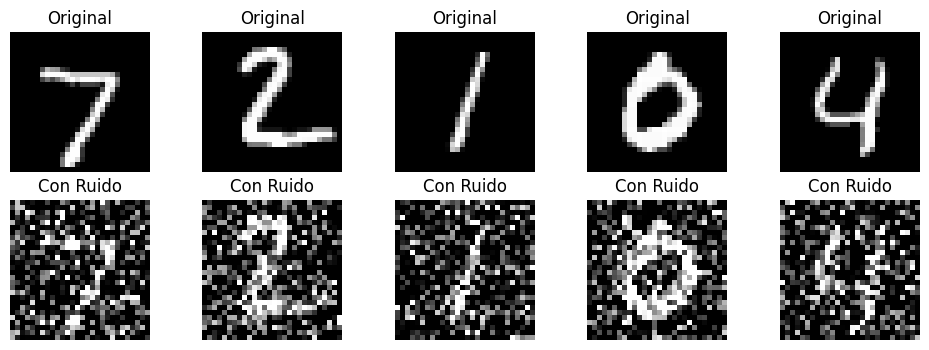

In [27]:
# VISUALIZACIÓN DEL RUIDO
n = 5

plt.figure(figsize=(12,4))

for i in range(n):

    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Imagen con ruido
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Con Ruido")
    plt.axis("off")

plt.show()

In [28]:
# MODELO
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Modelo completo
autoencoder = Model(input_img, decoded)

# Compilación
autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

# Resumen
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ENTRENAMIENTO
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=1,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

938/938 ━━━━━━━━━━━━━━━━━━━━ 164s 172ms/step - loss: 0.1411 - val_loss: 0.1090


In [22]:
# PREDICCIÓN
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


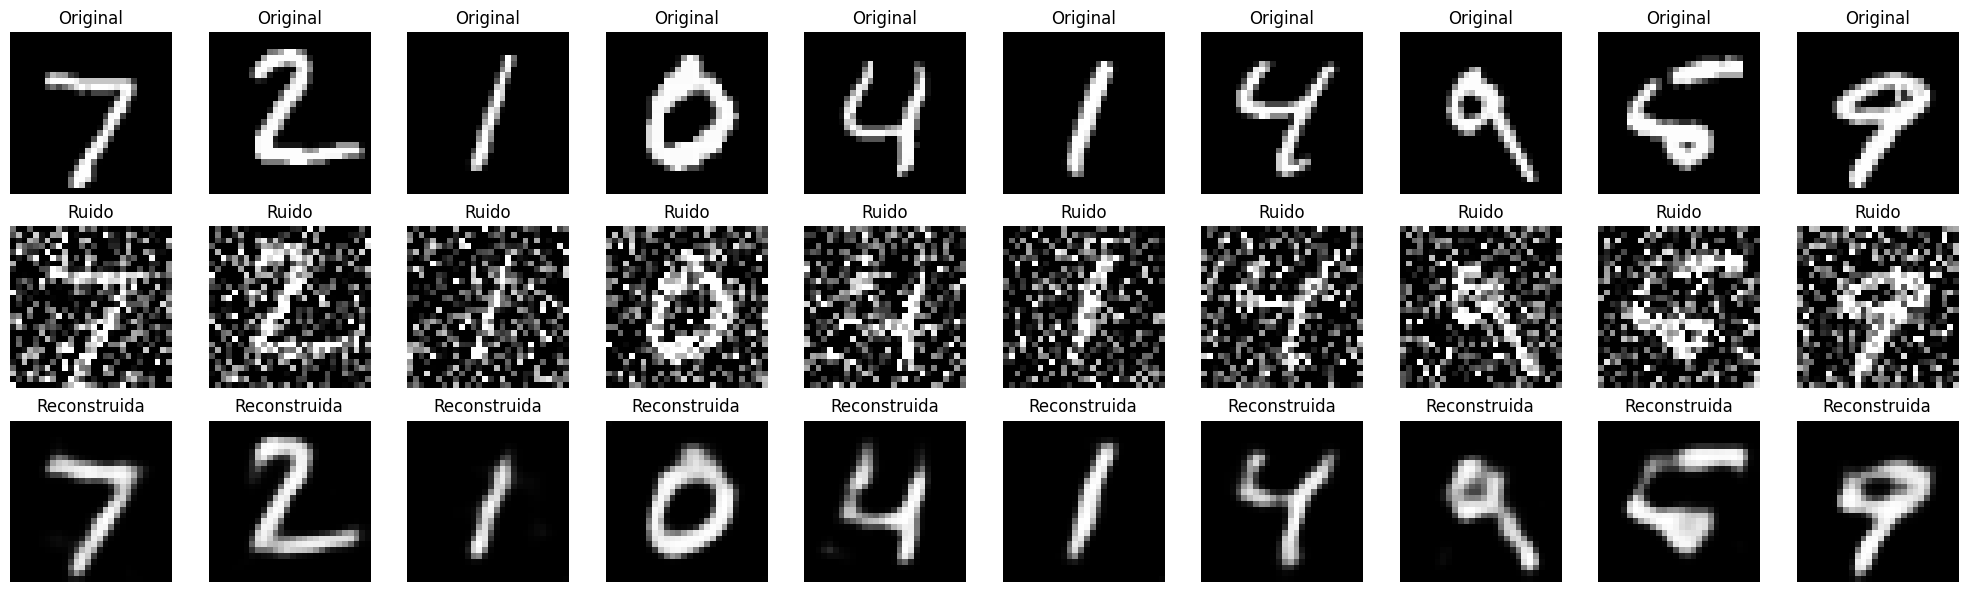

In [23]:
# COMPARACIÓN FINAL
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Con ruido
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Ruido")
    plt.axis("off")

    # Reconstruida
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstruida")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Análisis de Resultados

El modelo logró aprender características relevantes de los dígitos presentes en el dataset MNIST. Durante el entrenamiento se observó una disminución progresiva de la función de pérdida, indicando que el Autoencoder fue capaz de mejorar su capacidad de reconstrucción.

Las imágenes reconstruidas muestran una reducción significativa del ruido artificial añadido inicialmente, conservando la estructura principal de los dígitos. Aunque algunas imágenes presentan ligera pérdida de detalle, el modelo consigue recuperar adecuadamente la información esencial.

# Conclusiones
- Los Autoencoders representan una técnica eficiente de aprendizaje no supervisado para compresión y reconstrucción de datos.
- El modelo Denoising Autoencoder implementado logró eliminar gran parte del ruido presente en las imágenes del dataset MNIST.
- La arquitectura encoder-decoder permitió aprender representaciones comprimidas útiles para la reconstrucción posterior de imágenes limpias.
- El entrenamiento fue estable y rápido gracias al uso de TensorFlow/Keras y una arquitectura convolucional ligera.
- Entre las aplicaciones reales de los Autoencoders se encuentran:
  - eliminación de ruido en imágenes médicas,
  - compresión de datos,
  - detección de anomalías,
  - restauración de imágenes,
  - sistemas de recomendación,
  - procesamiento de señales.
- Los resultados obtenidos evidencian el potencial de las redes neuronales profundas para tareas de reconstrucción y representación de información.

# Referencias
- TensorFlow Documentation
- Keras Documentation
- Dataset MNIST
- Goodfellow, Ian. Deep Learning. MIT Press.